<a href="https://colab.research.google.com/github/Sticzer77/MEDICA/blob/main/colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## K-Nearest Neighbors (K-NN) Machine Learning System

This notebook demonstrates a simple K-Nearest Neighbors (K-NN) classification model using the Iris dataset. We will cover:
1.  **Loading Data**
2.  **Data Preprocessing**
3.  **Model Training**
4.  **Model Evaluation**

### 1. Loading the Data

We'll use the famous Iris dataset, which is readily available in `scikit-learn`. This dataset contains measurements of iris flowers and their corresponding species, making it suitable for classification tasks.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Załaduj zbiór danych Iris
iris = load_iris()
X = iris.data
y = iris.target

# Utwórz DataFrame dla lepszego podglądu
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y

print("Pierwsze 5 wierszy zbioru danych:")
display(df.head())

print("\nMapowanie gatunków:")
for i, species_name in enumerate(iris.target_names):
    print(f"{i}: {species_name}")

Pierwsze 5 wierszy zbioru danych:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Mapowanie gatunków:
0: setosa
1: versicolor
2: virginica


### 2. Data Preprocessing

Before training the model, we need to prepare the data:
*   **Split the data:** Divide the dataset into training and testing sets. The training set will be used to train the model, and the testing set will evaluate its performance on unseen data.
*   **Feature Scaling:** K-NN is a distance-based algorithm, meaning it's sensitive to the magnitude of the features. We'll use `StandardScaler` to normalize the features, ensuring all features contribute equally to the distance calculations.

In [ ]:
# Podziel dane na zestawy treningowy i testowy (80% trening, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Rozmiar zestawu treningowego: {X_train.shape[0]} próbek")
print(f"Rozmiar zestawu testowego: {X_test.shape[0]} próbek")

# Zainicjuj StandardScaler
scaler = StandardScaler()

# Dopasuj do danych treningowych i przetransformuj zarówno dane treningowe, jak i testowe
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nCechy zostały pomyślnie przeskalowane.")

Rozmiar zestawu treningowego: 120 próbek
Rozmiar zestawu testowego: 30 próbek

Cechy zostały pomyślnie przeskalowane.


### 3. Model Training

Now, we'll train the K-Nearest Neighbors classifier. The key parameter for K-NN is `n_neighbors`, which specifies the number of neighbors to consider when classifying a point. We'll start with `n_neighbors=5`.

In [ ]:
# Zainicjuj klasyfikator K-NN z n_neighbors = 5
knn = KNeighborsClassifier(n_neighbors=5)

# Trenuj model, używając przeskalowanych danych treningowych
knn.fit(X_train_scaled, y_train)

print("Model K-NN został pomyślnie wytrenowany z n_neighbors=5.")

Model K-NN został pomyślnie wytrenowany z n_neighbors=5.


### 4. Model Evaluation

After training, we evaluate the model's performance on the unseen test data. We'll look at:
*   **Accuracy:** The proportion of correctly classified samples.
*   **Confusion Matrix:** A table showing the number of correct and incorrect predictions for each class.
*   **Classification Report:** Provides precision, recall, and F1-score for each class, giving a more detailed view of performance.

Dokładność modelu: 1.0000

Macierz pomyłek:


,setosa,versicolor,virginica
setosa,10,0,0
versicolor,0,9,0
virginica,0,0,11



Raport klasyfikacji:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



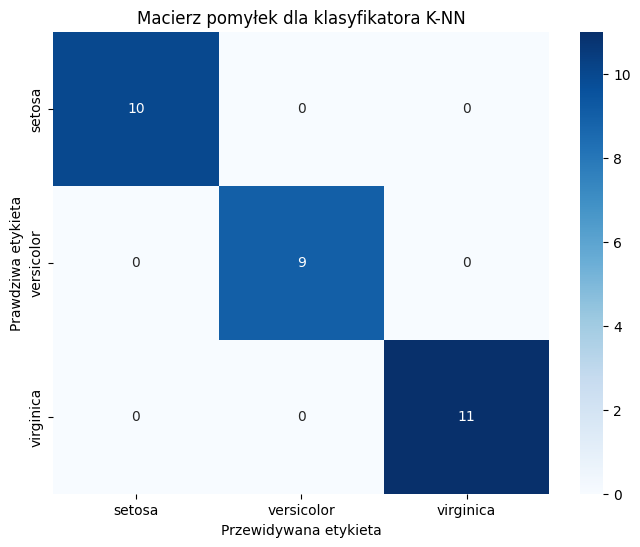

In [ ]:
# Wykonaj przewidywania na przeskalowanych danych testowych
y_pred = knn.predict(X_test_scaled)

# Oblicz dokładność
accuracy = accuracy_score(y_test, y_pred)
print(f"Dokładność modelu: {accuracy:.4f}")

# Wyświetl macierz pomyłek
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMacierz pomyłek:")
display(pd.DataFrame(conf_matrix, index=iris.target_names, columns=iris.target_names))

# Wyświetl raport klasyfikacji
class_report = classification_report(y_test, y_pred, target_names=iris.target_names)
print("\nRaport klasyfikacji:")
print(class_report)

# Opcjonalnie: Wizualizacja macierzy pomyłek
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Przewidywana etykieta')
plt.ylabel('Prawdziwa etykieta')
plt.title('Macierz pomyłek dla klasyfikatora K-NN')
plt.show()